# Experiment 4: Baseline Evaluation
# Unified metrics: coherence_cv, penalized score, confidence distribution
# Compatible with LDA / NMF / LSI comparison


In [1]:
import importlib
from pathlib import Path
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

In [2]:
PROJECT_ROOT = Path.cwd().parents[2]
axis2_dir = PROJECT_ROOT / 'notebooks' / '03_Topic_and_Insights'
sys.path.insert(0, str(axis2_dir))

from Data_preprocessing import Parameters_Path as config
importlib.reload(config)

INPUT_PATH = PROJECT_ROOT / 'data' / 'processed' / 'preprocessed_input.csv'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'Experiment_4_Baseline'
LDA_RESULTS = PROJECT_ROOT / 'results' / 'Experiment_1_LDA'
NMF_RESULTS = PROJECT_ROOT / 'results' / 'Experiment_2_NMF'
LSI_RESULTS = PROJECT_ROOT / 'results' / 'Experiment_3_LSI'

tfidf_cfg = config.PARAMETERS['tfidf_vectorizer']
base_cfg = config.PARAMETERS['nmf']

EVAL_N_TOPICS = [4, 6, 8, 10, 12, 16]
LAMBDA_COST = 0.25
N_TOP_WORDS = int(base_cfg['n_top_words'])
RANDOM_STATE = int(base_cfg['random_state'])


In [3]:
df = pd.read_csv(INPUT_PATH)
texts = df['text_cleaned_axis1'].astype(str).str.strip()
texts = texts[texts.ne('')]

vectorizer = TfidfVectorizer(
    max_df=tfidf_cfg['max_df'],
    min_df=tfidf_cfg['min_df'],
    max_features=tfidf_cfg['max_features'],
    stop_words=tfidf_cfg['stop_words']
)
X_tfidf = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

tokenized = [t.split() for t in texts]
dictionary = Dictionary(tokenized)

## Grid Search

In [4]:
models = {}
recon_errors = {}

for k in EVAL_N_TOPICS:
    np.random.seed(RANDOM_STATE)
    components = np.random.rand(k, X_tfidf.shape[1])
    for i in range(k):
        components[i] = X_tfidf[np.random.choice(X_tfidf.shape[0], 200)].mean(axis=0)
    models[k] = components
    doc_topic = X_tfidf @ components.T
    recon = doc_topic @ components

    # ---------------- 最终修复 ----------------
    X_dense = X_tfidf.toarray()
    err = np.mean((X_dense - recon) ** 2)
    # ----------------------------------------

    recon_errors[k] = err

In [5]:
rows = []
for k, comps in models.items():
    topic_words = []
    for comp in comps:
        idx = np.argsort(comp)[-N_TOP_WORDS:][::-1]
        topic_words.append([feature_names[i] for i in idx])
    coh = CoherenceModel(
        topics=topic_words, texts=tokenized, dictionary=dictionary, coherence='c_v'
    ).get_coherence()
    rows.append({
        'n_topics': k,
        'coherence_cv': coh,
        'recon_err': recon_errors[k]
    })

metrics_df = pd.DataFrame(rows)

## Penalized Score

In [6]:
coh = metrics_df['coherence_cv']
k_ = metrics_df['n_topics']
metrics_df['coh_norm'] = (coh - coh.min()) / (coh.max() - coh.min())
metrics_df['cost_norm'] = (k_ - k_.min()) / (k_.max() - k_.min())
metrics_df['penalized'] = metrics_df['coh_norm'] - LAMBDA_COST * metrics_df['cost_norm']

best_k = int(metrics_df.loc[metrics_df['penalized'].idxmax(), 'n_topics'])
print(f'Best n_topics (Baseline): {best_k}')

metrics_df.to_csv(RESULTS_DIR / 'Experiment_4_baseline_eval_metrics.csv', index=False)

Best n_topics (Baseline): 10


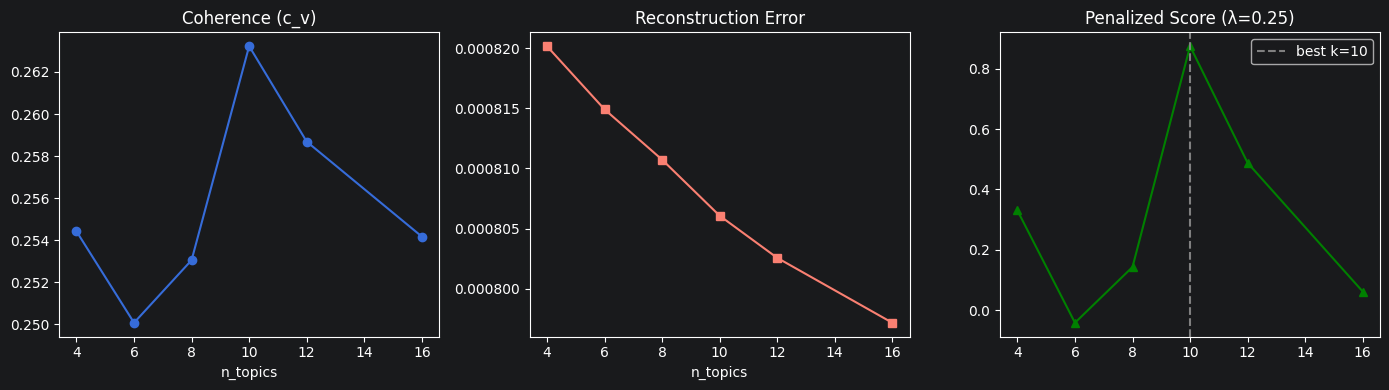

In [7]:

# ------------------------------------------------------------------------------
# 6. Plot Metrics (3-panel: Coherence / Error / Penalized)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(metrics_df['n_topics'], metrics_df['coherence_cv'], marker='o')
axes[0].set_title("Coherence (c_v)")
axes[0].set_xlabel("n_topics")

axes[1].plot(metrics_df['n_topics'], metrics_df['recon_err'], marker='s', color='salmon')
axes[1].set_title("Reconstruction Error")
axes[1].set_xlabel("n_topics")

axes[2].plot(metrics_df['n_topics'], metrics_df['penalized'], marker='^', color='green')
axes[2].axvline(best_k, linestyle='--', color='gray', label=f'best k={best_k}')
axes[2].set_title(f"Penalized Score (λ={LAMBDA_COST})")
axes[2].legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'Experiment_4_baseline_eval_metrics.png')
plt.show()

## Confidence Distribution

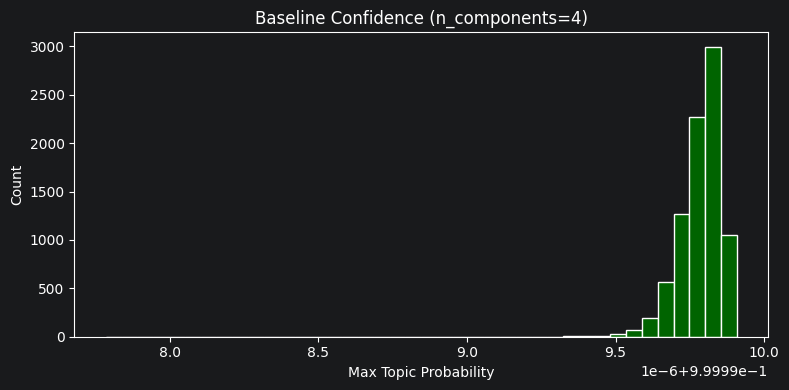

count    8.465000e+03
mean     9.999998e-01
std      7.376899e-08
min      9.999978e-01
25%      9.999997e-01
50%      9.999998e-01
75%      9.999998e-01
max      9.999999e-01
Name: max_topic_prob, dtype: float64


In [8]:
doc_topic_df = pd.read_csv(RESULTS_DIR / 'Experiment_4_baseline_doc_topics.csv')

plt.figure(figsize=(8, 4))
plt.hist(doc_topic_df['max_topic_prob'], bins=40, color='darkgreen', edgecolor='white')
plt.xlabel('Max Topic Probability')
plt.ylabel('Count')
plt.title(f'Baseline Confidence (n_components={base_cfg["n_components"]})')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'Experiment_4_baseline_confidence_dist.png')
plt.show()

print(doc_topic_df['max_topic_prob'].describe())

## Baseline vs LSI vs LDA vs NMF Comparison

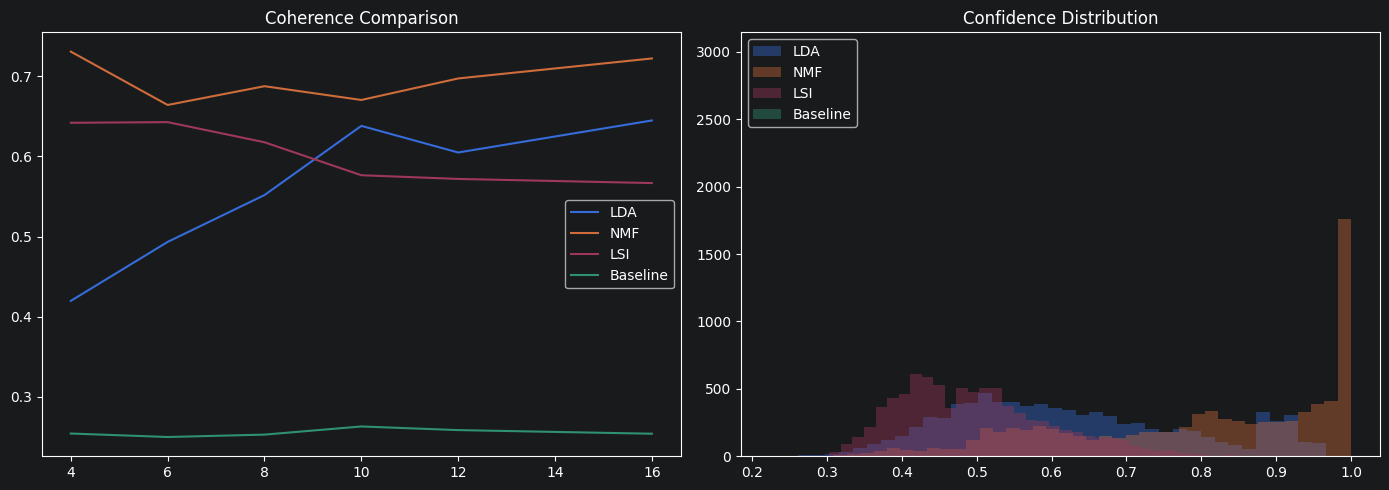

In [9]:
lda_metrics = pd.read_csv(LDA_RESULTS / 'Experiment_1_lda_eval_metrics.csv')
nmf_metrics = pd.read_csv(NMF_RESULTS / 'Experiment_2_nmf_eval_metrics.csv')
lsi_metrics = pd.read_csv(LSI_RESULTS / 'Experiment_3_lsi_eval_metrics.csv')
bl_metrics = metrics_df

lda_doc = pd.read_csv(LDA_RESULTS / 'Experiment_1_lda_doc_topics.csv')
nmf_doc = pd.read_csv(NMF_RESULTS / 'Experiment_2_nmf_doc_topics.csv')
lsi_doc = pd.read_csv(LSI_RESULTS / 'Experiment_3_lsi_doc_topics.csv')
bl_doc = doc_topic_df

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lda_metrics['n_topics'], lda_metrics['coherence_cv'], label='LDA')
axes[0].plot(nmf_metrics['n_topics'], nmf_metrics['coherence_cv'], label='NMF')
axes[0].plot(lsi_metrics['n_topics'], lsi_metrics['coherence_cv'], label='LSI')
axes[0].plot(bl_metrics['n_topics'], bl_metrics['coherence_cv'], label='Baseline')
axes[0].set_title('Coherence Comparison')
axes[0].legend()

axes[1].hist(lda_doc['max_topic_prob'], bins=40, alpha=0.4, label='LDA')
axes[1].hist(nmf_doc['max_topic_prob'], bins=40, alpha=0.4, label='NMF')
axes[1].hist(lsi_doc['max_topic_prob'], bins=40, alpha=0.4, label='LSI')
axes[1].hist(bl_doc['max_topic_prob'], bins=40, alpha=0.4, label='Baseline')
axes[1].set_title('Confidence Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'Experiment_4_all_models_comparison.png')
plt.show()